<a href="https://colab.research.google.com/github/maheck9/SynapseLP/blob/week6/MahekCV_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CV Task 1**

## **Synapse Learning Period**
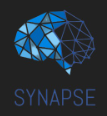

Congratulations on finishing the basic learning period! Now you will specialise in one of the most interesting domains in ML: Computer Vision. If you have been living under a rock and *still* don't know what that is, go through the below link:

https://towardsdatascience.com/everything-you-ever-wanted-to-know-about-computer-vision-heres-a-look-why-it-s-so-awesome-e8a58dfb641e

So yeah, a lot of cool stuff can be done with CV. But before we progress to doing that cool stuff, your basics need to be made very sound, which is what completing this task will do for you.

https://www.datacamp.com/blog/what-is-computer-vision

## mounting drive and importing stuff

In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import math
%matplotlib inline

## opencv basics

Before we get into this, what even is an image? Get your basics cleared from below:

https://www.analyticsvidhya.com/blog/2021/03/grayscale-and-rgb-format-for-storing-images/

To actually preprocess an image, lets use the wget command to actually import one first.

 * wget is a linux command that helps us download content from the web.
 * we can use the -O flag to store it using a custom name.
 * all linux commands can be accessed in jupyter notebooks using ! before the command.

In [3]:
!wget -O pika.jpg https://upload.wikimedia.org/wikipedia/en/a/a6/Pok%C3%A9mon_Pikachu_art.png

--2026-01-06 21:57:14--  https://upload.wikimedia.org/wikipedia/en/a/a6/Pok%C3%A9mon_Pikachu_art.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53612 (52K) [image/png]
Saving to: ‘pika.jpg’

pika.jpg            100%[===================>]  52.36K  --.-KB/s    in 0.001s  

2026-01-06 21:57:14 (35.9 MB/s) - ‘pika.jpg’ saved [53612/53612]



In [4]:
# linux command to see files in current directory.
!ls

gdrive	pika.jpg  sample_data


<h2>Understanding images</h2>

https://medium.com/@md-jewel/understanding-digital-images-for-image-processing-and-computer-vision-part-1-cc42be78cca1

GOAT, but thodu sa advanced: https://www.datacamp.com/tutorial/seeing-like-a-machine-a-beginners-guide-to-image-analysis-in-machine-learning

Thoda hype karne ke liye :) https://opencv.org/blog/computer-vision-and-image-processing/

Masterpiece: https://www.analyticsvidhya.com/blog/2021/03/grayscale-and-rgb-format-for-storing-images/

We read the image using cv.imread().
Then we use plt.imshow() to show the image.

(Why not cv.imshow(), you may ask? For that, refer to the below link:

https://stackoverflow.com/questions/55288657/image-is-not-displaying-in-google-colab-while-using-imshow)

Ans :In your laptop environment (a normal Python script),
cv.imshow() pops up a separate window displaying the image.

But Google Colab and Jupyter do NOT support GUI windows.
They run inside a browser.
There is no desktop window manager to open an image window.

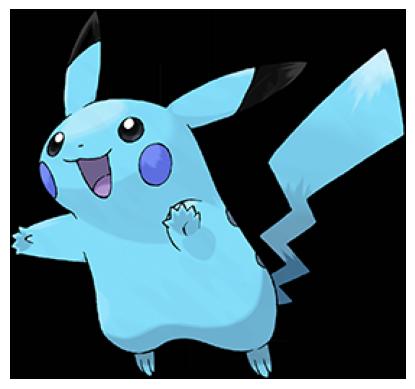

In [5]:
image = cv.imread("pika.jpg")
plt.axis('off')
plt.imshow(image)

Why is Pikachu looking like it is doing some very weird Smurf cosplay? Google it and try to find out the reason. Then fix it in the below code cell.

OpenCV loads images in BGR format (Blue, Green, Red).
Matplotlib displays images in RGB format (Red, Green, Blue).

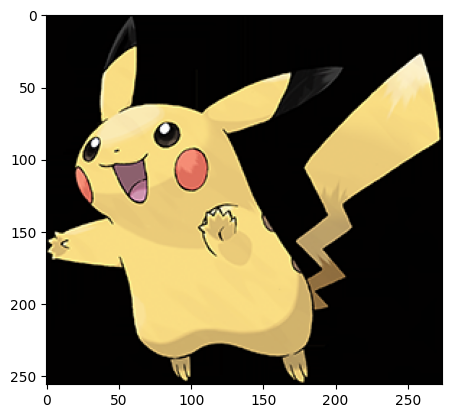

In [6]:
# output should look like the one shown below.
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
plt.imshow(image_rgb)


Try changing sequence of color channels, and see how the image changes

In [7]:
b, g, r = cv.split(image)
rbg = cv.merge([r, b, g])
grb = cv.merge([g, r, b])
gbr = cv.merge([g, b, r])
brg = cv.merge([b, r, g])
#bgr and rgb is done





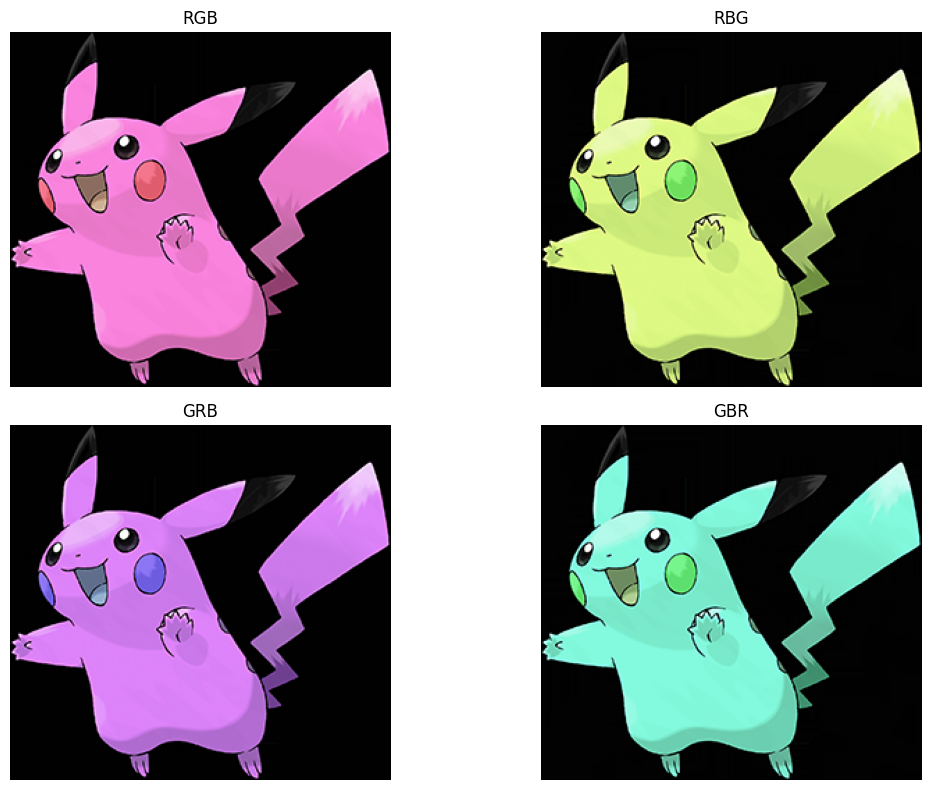

In [8]:
titles = ['RGB', 'RBG', 'GRB', 'GBR', 'BRG', 'BGR']
images = [rbg, grb, gbr, brg]

plt.figure(figsize=(12, 8))
#plot it all together like 4 cells
for i in range(4):
    plt.subplot(2, 2, i+1) #i+1 tells Matplotlib which position to place each image in
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off') #removes axis ticks - basically y axis and x axis

plt.tight_layout() #prevents overlapping
plt.show()


Google the one line code to convert image to grayscale in OpenCV and convert the downloaded image to grayscale. Plot the image using plt.imshow(). Remember to set the color map to "gray" (cmap = "gray") in plt.imshow() as plt automatically adds a color filter which is not needed.

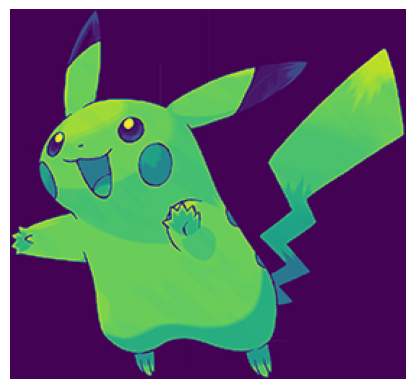

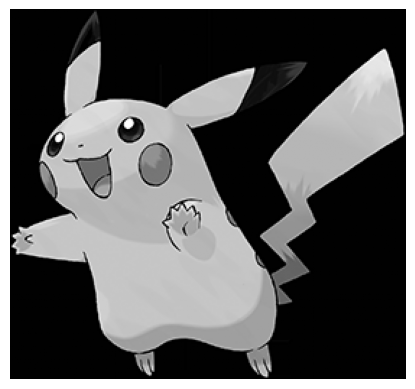

In [9]:
# convert RGB image to grayscale
image_gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)

#Without cmap
plt.imshow(image_gray) #here we don't tell it which color map to use so it used virdis which is neon based hence neon pikachu
plt.axis('off')
plt.show()

#With cmap
plt.imshow(image_gray, cmap='gray') #here i mentioned colour map to be grey scale hence 1900s pikachu
plt.axis('off')
plt.show()


In [10]:
!wget -O charizard.png https://upload.wikimedia.org/wikipedia/en/1/1f/Pok%C3%A9mon_Charizard_art.png

--2026-01-06 21:57:16--  https://upload.wikimedia.org/wikipedia/en/1/1f/Pok%C3%A9mon_Charizard_art.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94104 (92K) [image/png]
Saving to: ‘charizard.png’

charizard.png       100%[===================>]  91.90K  --.-KB/s    in 0.003s  

2026-01-06 21:57:16 (31.3 MB/s) - ‘charizard.png’ saved [94104/94104]



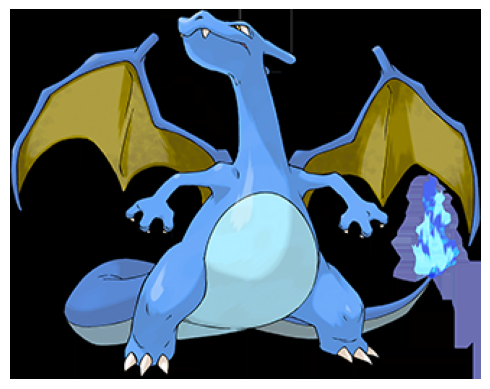

In [11]:
image2 = cv.imread("charizard.png")
plt.axis('off')
plt.imshow(image2)

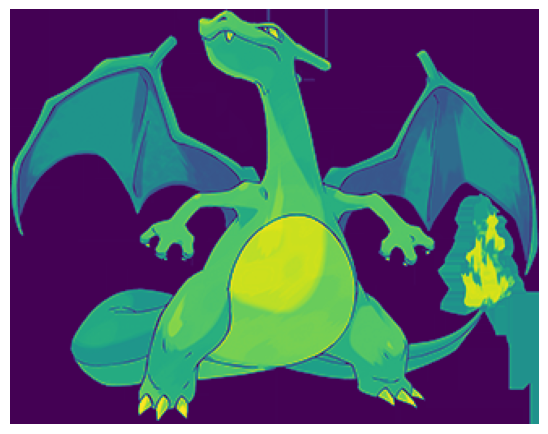

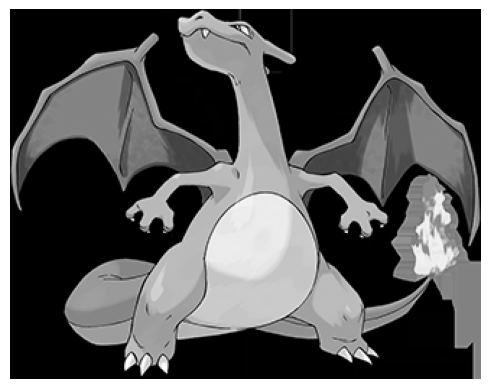

In [12]:
plt.figure(figsize=(15,6))

#Original Pic with BGR
'''Why is BGR and RGB different?'''
#cause it takes blue first so like blue tinted ho raha hai
plt.subplot(1,2,1)
image2_gray = cv.cvtColor(image2, cv.COLOR_BGR2GRAY)
#Without cmap
plt.imshow(image2_gray)
plt.axis('off')
plt.show()

#With cmap
plt.imshow(image2_gray, cmap='gray')
plt.axis('off')
plt.show()

Now convert BGR to RGB and BRG

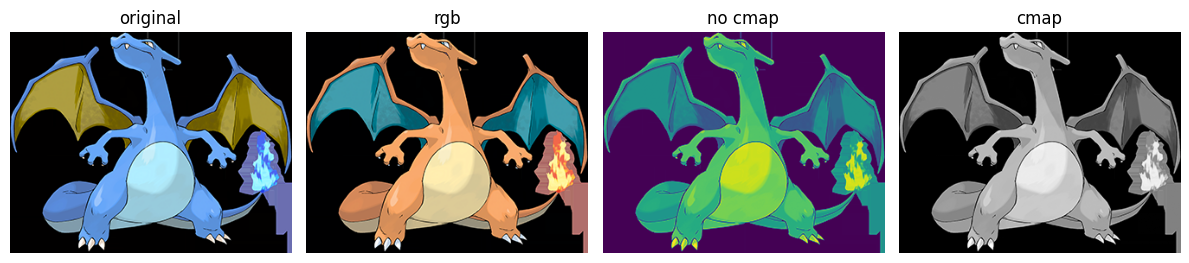

In [13]:

# Original BGR
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image2)
plt.title("original")
plt.axis('off')

#RGB charizard
image2_rgb = cv.cvtColor(image2, cv.COLOR_BGR2RGB)
plt.subplot(1,4,2)
plt.imshow(image2_rgb)
plt.title("rgb")
plt.axis('off')

#without cmap
plt.subplot(1,4,3)
plt.imshow(image2_gray)
plt.title("no cmap")
plt.axis('off')

#with cmap
plt.subplot(1,4,4)
plt.imshow(image2_gray, cmap='gray')
plt.title("cmap")
plt.axis('off')

plt.tight_layout()
plt.show()


Use cv2.resize() to resize your image to (200, 200) and then show it using plt.

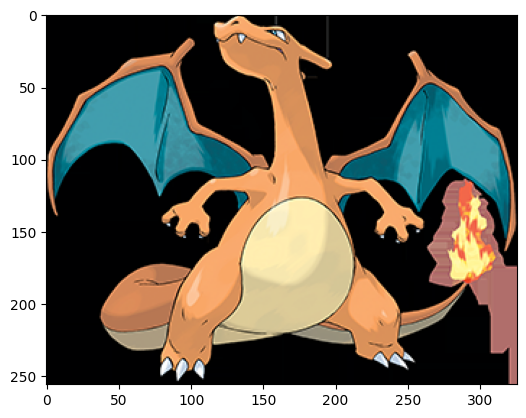

In [14]:
#Before resizing
plt.imshow(image2_rgb)

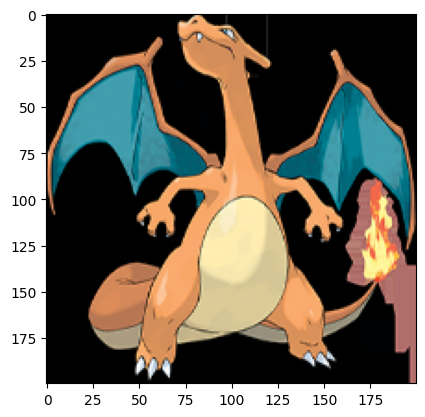

In [15]:
# resize image here.
image2_resize = cv.resize(image2_rgb, (200, 200))
plt.imshow(image2_resize)
#After resizing

In [16]:
# the resized image now has shape (200, 200, 3).

Write code for cropping the image from height 70 to 150 and width 50 to 120. Hint: be smart with your slicing while displaying the image.

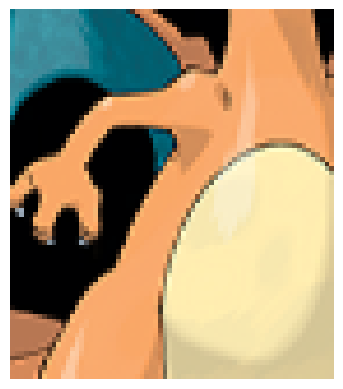

In [17]:
# crop image here. desired output is as shown below.
cropped_image2 = image2_resize[70:150, 50:120] #image[y1:y2, x1:x2]

plt.imshow(cropped_image2)
plt.axis('off')
plt.show()


We can also draw lines on images with OpenCV. Lets make our Pikachu buff with some abs.

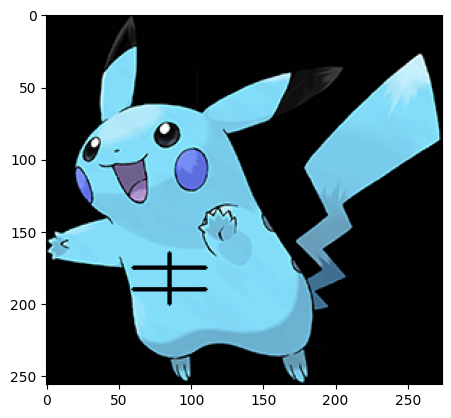

In [18]:
# horizontal lines.
buff_pikachu = cv.line(image.copy(), (60, 175), (110, 175), (0, 0, 0), 2)
buff_pikachu = cv.line(buff_pikachu, (60, 190), (110, 190), (0, 0, 0), 2)

# vertical line.
buff_pikachu = cv.line(buff_pikachu, (85, 200), (85, 165), (0, 0, 0), 2)
# i kept the axis for better understanding.
#plt.imshow(cv.cvtColor(buff_pikachu, cv.COLOR_BGR2RGB))
plt.imshow(buff_pikachu)

Draw random (sfw) stuff on pikachu. Any shape, any figure is allowed. Resource:
https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html

Best design will get something special :)

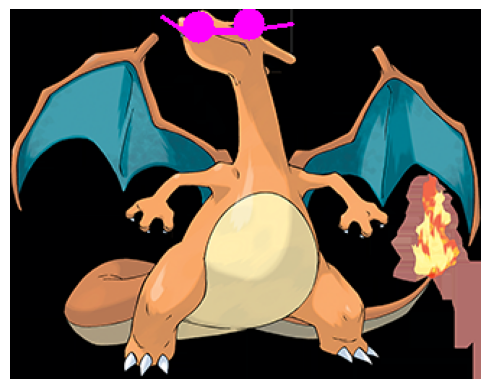

In [75]:
mom_charizard = image2_rgb.copy()

# LEFT lens (left eye)
cv.circle(
    mom_charizard,
    (165, 10),   # x left, y HIGH
    11,
    (255, 0, 255),
    -1
)

# RIGHT lens (right eye)
cv.circle(
    mom_charizard,
    (130, 12),   # slightly higher because head is tilted
    11,
    (255, 0, 255),
    -1
)


# top frame
cv.line(
    mom_charizard,
    (120, 15),   # slightly wider + UP
    (160, 15),
    (255, 0, 255),
    3
)
# LEFT arm of specs
cv.line(
    mom_charizard,
    (120, 15),   # start from left end of frame
    (105, 5),   # go diagonally back
    (255, 0, 255),
    2
)

# RIGHT arm of specs
cv.line(
    mom_charizard,
    (160, 15),   # start from right end of frame
    (195, 10),   # go diagonally back
    (255, 0, 255),
    2
)


plt.imshow(mom_charizard)
plt.axis('off')
plt.show()




## convolution

Before we do move ahead, we feel it important that you clearly understand what convolution is. A lot of stuff in preprocessing and in edge detection also involves convolving images.

Y'all must have studied the formula for convolution of two functions somewhere in your Engineering Maths III portion. If not, this is what the formula for it looks like:

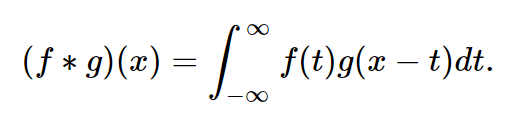

Yeah, they must have skipped over the part about how it is actually useful and just made you do a million integrals for it. To get a feel for what it exactly is, go through the resource below:

https://youtu.be/KuXjwB4LzSA?si=wc7iLGuUYEOw8TwA

As you may now know, it has use cases all over mathematics. But from an image processing point of view, this below GIF is essentially what it looks like:

<img src='https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif' alt='how to  a gif to your page' height='350px'>

For a clearer explanation, see the below video:

https://youtu.be/Etksi-F5ug8?si=pXAvAQJtPKa0s19v

All that should have made your concepts extremely clear. If not, go through the resources again.

Time to get your hands dirty now. As you may have realised, we first flip the kernel before convolving the image. So, write a function for flipping a two dimensional matrix horizontally from scratch. Try do an in-place flip to improve space complexity.

In [20]:

  # replace pass with a return statement. use your own logic here.
  # DON'T use any in-built function here
  # hint: look into something called the two pointers approach for an optimised solution.
  def flip_hori(kernel):
    rows = len(kernel)

    for r in range(rows):
        left = 0
        right = len(kernel[r]) - 1

        # Swap left & right elements until they meet
        while left < right:
            kernel[r][left], kernel[r][right] = kernel[r][right], kernel[r][left]
            left += 1
            right -= 1

    return kernel




--2026-01-06 21:57:20--  https://www.pokemon.com/static-assets/content-assets/cms2/img/pokedex/full/150.png
Resolving www.pokemon.com (www.pokemon.com)... 45.60.125.52
Connecting to www.pokemon.com (www.pokemon.com)|45.60.125.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 119320 (117K) [image/png]
Saving to: ‘mewtwo.png’

mewtwo.png          100%[===================>] 116.52K  --.-KB/s    in 0.009s  

2026-01-06 21:57:20 (12.8 MB/s) - ‘mewtwo.png’ saved [119320/119320]

og kernel:
[1, 2, 3]
[4, 5, 6]
[7, 8, 9]

Flipped kernel:
[3, 2, 1]
[6, 5, 4]
[9, 8, 7]


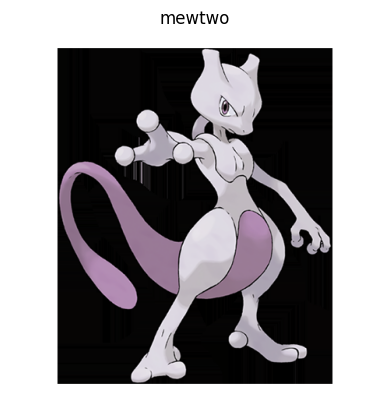

In [21]:
#Perform the above function on a dummy 'image' and kernel
!wget -O mewtwo.png "https://www.pokemon.com/static-assets/content-assets/cms2/img/pokedex/full/150.png"
mewtwo = cv.imread("mewtwo.png")
mewtwo_rgb = cv.cvtColor(mewtwo, cv.COLOR_BGR2RGB)

plt.imshow(mewtwo_rgb)
plt.axis('off')
plt.title("mewtwo")
#Kernel
kernel = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]

#Operate
print("og kernel:")
for row in kernel:
    print(row)

flipped = flip_hori([row[:] for row in kernel]) #make a copy so the og one doesnt change

print("\nFlipped kernel:")
for row in flipped:
    print(row)


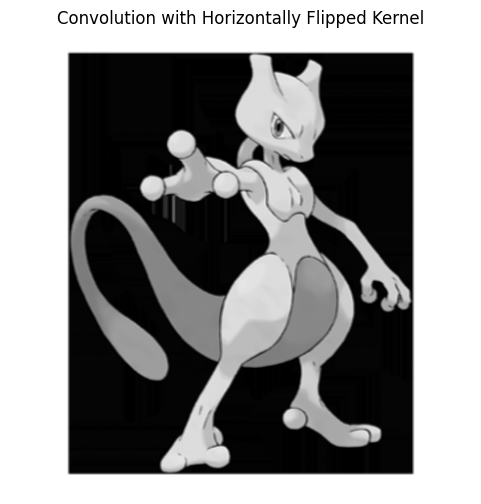

In [22]:
#convolution - understand this!!

def convolve(image, kernel):
    img_h, img_w = image.shape
    k = len(kernel)  # assume square kernel (3x3)
    pad = k // 2

    # output size same as input but ignore edges without padding
    output = np.zeros((img_h - 2*pad, img_w - 2*pad))

    # flip kernel as per convolution rule
    kernel = np.array(kernel)[::-1, ::-1]  # full flip

    # sliding window
    for i in range(pad, img_h - pad):
        for j in range(pad, img_w - pad):
            region = image[i-pad:i+pad+1, j-pad:j+pad+1]
            output[i-pad, j-pad] = np.sum(region * kernel)

    return output

  # Convert mewtwo to grayscale for convolution
mewtwo_gray = cv.cvtColor(mewtwo_rgb, cv.COLOR_RGB2GRAY)

# Apply convolution on grayscale image using horizontal kernel
output_hori = convolve(mewtwo_gray, flipped)

plt.figure(figsize=(6,6))
plt.imshow(output_hori, cmap='gray')
plt.title("Convolution with Horizontally Flipped Kernel")
plt.axis('off')
plt.show()



In [23]:
#Flip the image vertically
def flip_vert(matrix):
    top = 0
    bottom = len(matrix) - 1

    # swap rows while top pointer is above bottom pointer
    while top < bottom:
        matrix[top], matrix[bottom] = matrix[bottom], matrix[top]
        top += 1
        bottom -= 1

    return matrix


og kernel:
[1, 2, 3]
[4, 5, 6]
[7, 8, 9]
Vertically flipped kernel:
[7, 8, 9]
[4, 5, 6]
[1, 2, 3]


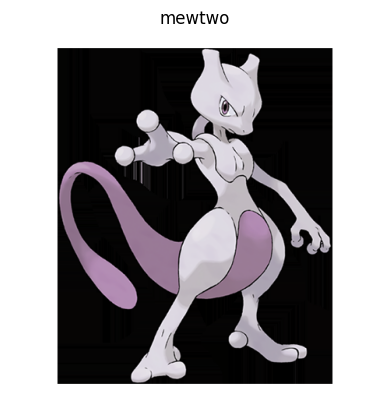

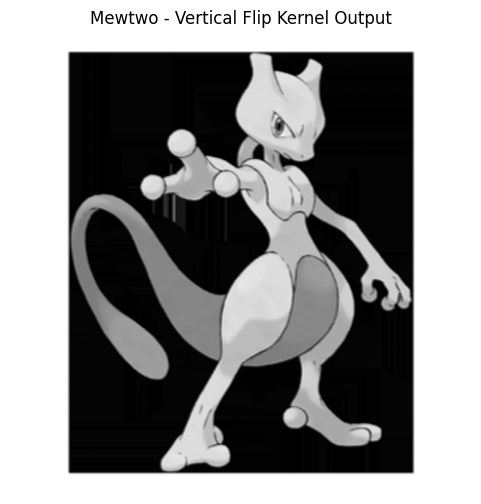

In [24]:
#Perform the above function on a dummy 'image' and kernel

plt.imshow(mewtwo_rgb)
plt.axis('off')
plt.title("mewtwo")
#Kernel
kernel = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]

#Operate
print("og kernel:")
for row in kernel:
    print(row)

flipped2 = flip_vert([row[:] for row in kernel]) #make a copy so the og one doesnt change

print("Vertically flipped kernel:")
for row in flipped2:
    print(row)

output_vert = convolve(mewtwo_gray, flipped2)

plt.figure(figsize=(6,6))
plt.imshow(output_vert, cmap='gray')
plt.title("Mewtwo - Vertical Flip Kernel Output")
plt.axis('off')
plt.show()



In [25]:
# run this cell as it is to check the output.

# using a copy as the function does the flipping in-place.

Now, write a function to perform basic convolution. Assume that the image is grayscale so there is only one channel instead of the usual RBG channels. Note that kernels will always be a square matrix while an image can be of any shape.

Hint: Use slicing instead of for loops while performing addition operations.

In [26]:
def convolution(kernel, image):


    img_h, img_w = image.shape #extract image height and weight

    k = len(kernel)  #kernel size (7*7)

    pad = k // 2

    # Create output image with reduced size (no padding)
    # Example: If kernel is 3x3 → remove 1 pixel border on all sides
    output = np.zeros((img_h - 2*pad, img_w - 2*pad))

    # Full flip kernel for VALID convolution (180°)
    # [: : -1, : : -1] flips row order AND each row's order
    kernel = np.array(kernel)[::-1, ::-1]

    # Sliding window convolution
    for i in range(pad, img_h - pad):  # ignore top/bottom edges
        for j in range(pad, img_w - pad):  # ignore left/right edges

            # Extract region of same size as kernel
            region = image[i-pad:i+pad+1, j-pad:j+pad+1]

            # Multiply elementwise and sum → one pixel
            output[i-pad, j-pad] = np.sum(region * kernel)

    return output




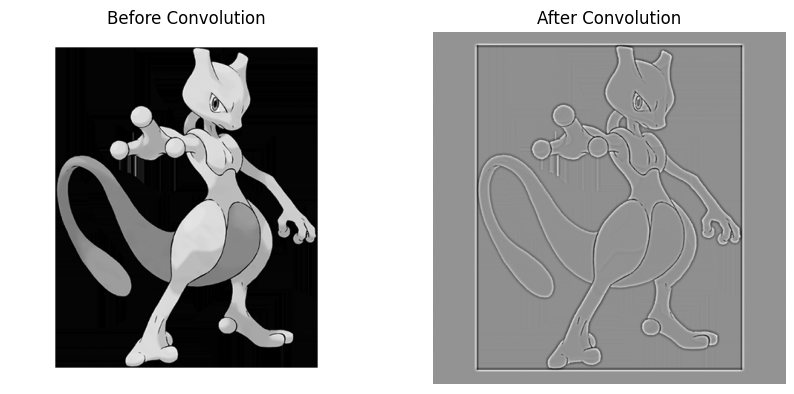

Shape before convolution = (475, 475)
Shape after convolution = (469, 469)


In [27]:
gray_img = cv.cvtColor(mewtwo, cv.COLOR_BGR2GRAY)

# run this cell as it is to check the output.
kernel2 = np.array([
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, 49, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1]
]) # 7 x 7 kernel to sharpen images.

conv_output = convolution(kernel2, gray_img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Before Convolution")
plt.imshow(gray_img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("After Convolution")
plt.imshow(conv_output, cmap='gray')
plt.axis('off')
plt.show()

print("Shape before convolution =", gray_img.shape)
print("Shape after convolution =", conv_output.shape)



Here, you can see that we lose the border pixels (notice that pikachu's toes and fingers have been nibbled at by our kernel).

What if we want to ensure the output image is the same size as that of the input image? There we use something called padding. Resource:

https://youtu.be/PGBop7Ka9AU?si=zWKktXnDL1bN_iCE

Also, there is something called "stride" in convolution as well. Resource:

https://youtu.be/lxk_nmpqI5M?si=SCnShMXeGLRyDsBj

Implement a convolution function with stride in parameters. Use zero padding to pad the images.

In [28]:
def convolution_with_stride(kernel, image, stride):
    # Convert image to numpy array in case it’s not
    image = np.array(image)

    # Get image dimensions
    img_h, img_w = image.shape

    # Get kernel size
    f = len(kernel)

    # Flip kernel 180
    kernel = np.array(kernel)[::-1, ::-1]

    #calculate padding size
    pad = f // 2

    #use zero padding
    padded_image = np.pad(image, pad, mode='constant')

    #get output dimensions
    out_h = (img_h + 2*pad - f) // stride + 1
    out_w = (img_w + 2*pad - f) // stride + 1

#kind of lost here - ask
    # Initialize output matrix
    output = np.zeros((out_h, out_w))

    # Sliding window based on stride
    for i in range(0, out_h):
        for j in range(0, out_w):
            # Extract the region where kernel is applied
            region = padded_image[i*stride : i*stride + f,
                                  j*stride : j*stride + f]
            # Multiply and sum → convolution result
            output[i, j] = np.sum(region * kernel)

    return output




Shape before convolution = (475, 475, 3)
Shape after convolution = (475, 475)


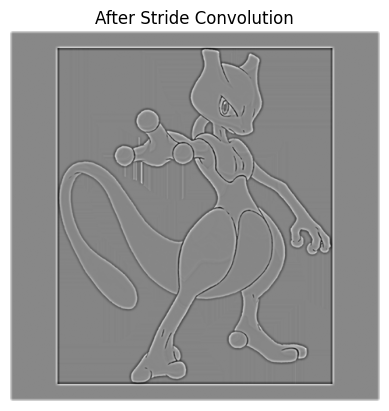

In [29]:
print("Shape before convolution =", mewtwo.shape)

result = convolution_with_stride(kernel2, mewtwo_gray, stride=1)

print("Shape after convolution =", result.shape)

plt.imshow(result, cmap='gray')
plt.axis('off')
plt.title("After Stride Convolution")
plt.show()


This maintains both the original shape of the image as well as Pikachu's toes and fingers.

Play around with the stride parameter to see how it affects the convolution operation and its shape.

play later

interactive(children=(IntSlider(value=8, description='stride', max=16, min=1), Output()), _dom_classes=('widge…

<function __main__.stride_change(stride)>

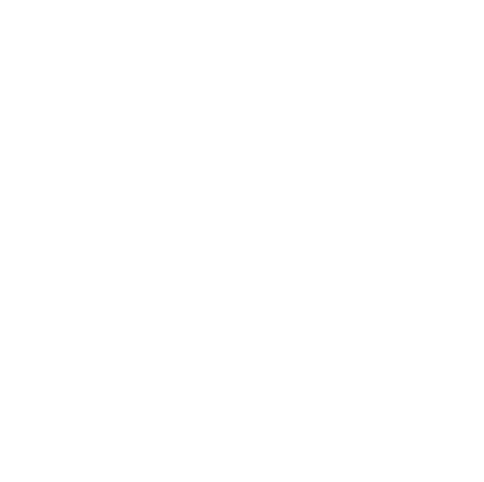

In [30]:
# playground.
from ipywidgets import interact

def stride_change(stride):
  plt.figure(figsize=(6,6))
  plt.axis('off')
  plt.imshow(convolution_with_stride(kernel, IMAGE, stride), cmap = 'gray')
  plt.title(f"Shape: {convolution_with_stride(kernel, IMAGE, stride).shape}")
  plt.show()

interact(stride_change, stride=(1, 16, 1))

In the last task, we saw that we could do all of the above with Tensorflow. So why did we make you do all this? Because the underlined parameters in the below image of Conv2D layer's parameters will now make much more sense.

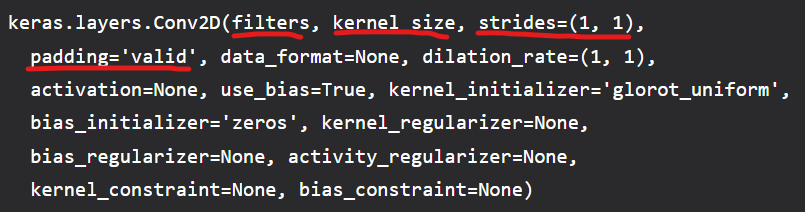

Apart from clearing your convolution concepts, it also hopefully made y'all realise the importance of DSA and how much thought goes into each inbuilt function that we usually directly import and apply. It is basic stuff like this that is sometimes modified into LeetCode problems. Examples:

https://leetcode.com/problems/flipping-an-image/

https://leetcode.com/problems/rotate-image/

## preprocessing images

That was a lot of brouhaha over convolution. Hopefully your functions are correct (test them out before starting this part!), as they are now going to be used for image preprocessing.

Just like we would preprocess DataFrames before actually doing any ML with them in the previous tasks, images need to be preprocessed first before applying algorithms on them as well. Resource:

https://www.analyticsvidhya.com/blog/2023/03/getting-started-with-image-processing-using-opencv/

A lot of preprocessing is just using special kernels to convolve over an image to yield certain output. The below images shows some staple kernel and their usecases.

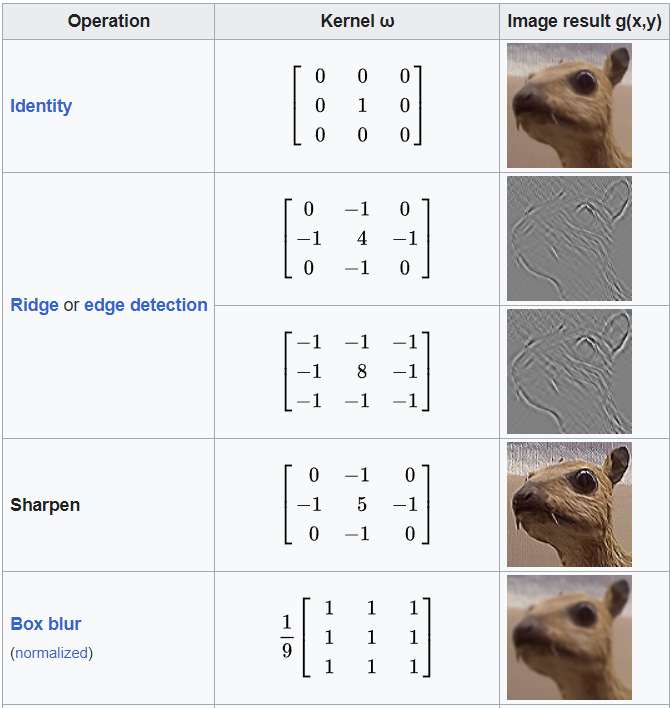
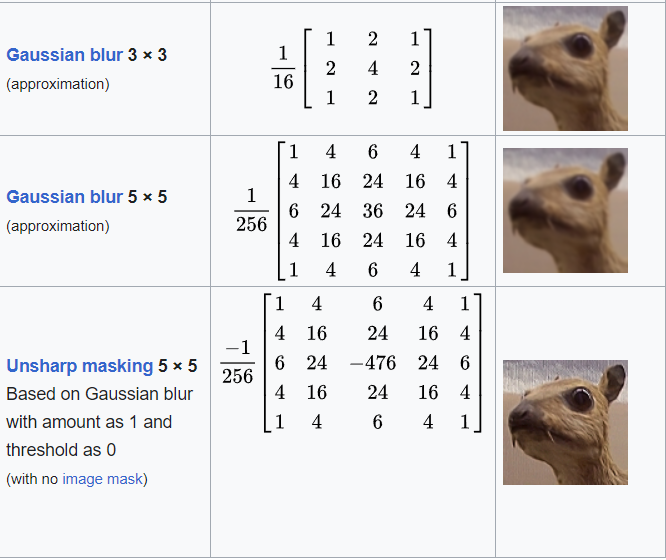

The earlier kernel we applied to test our convolution functions is called a sharpening filter, used used to accentuate the edges of the image and add contrast to them.

# Blurring

Blurring is used to reduce noise in the image. The most common type is Gaussian Blur. Resource:

https://youtu.be/C_zFhWdM4ic?si=RPWKZi6MvS7SX32v

i kind of have a doubt here how does the result get computed

Let us apply Gaussian Blur on our given Pikachu image. The earlier convolution functions you've written will be quite handy now.

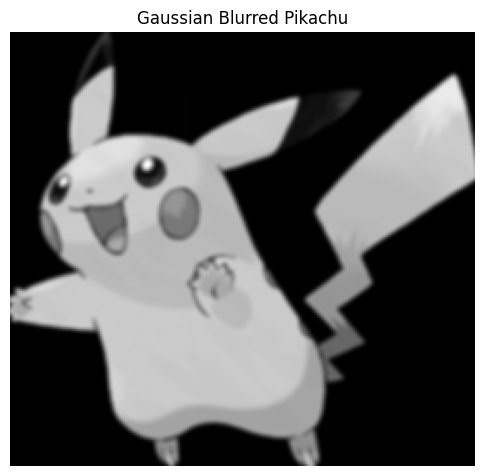

In [31]:
# run this cell as it is.
gb_kernel = np.array([
    [0.000798, 0.006581, 0.013347, 0.018614, 0.013347, 0.006581, 0.000798],
    [0.006581, 0.054223, 0.109394, 0.152377, 0.109394, 0.054223, 0.006581],
    [0.013347, 0.109394, 0.221008, 0.307116, 0.221008, 0.109394, 0.013347],
    [0.018614, 0.152377, 0.307116, 0.427661, 0.307116, 0.152377, 0.018614],
    [0.013347, 0.109394, 0.221008, 0.307116, 0.221008, 0.109394, 0.013347],
    [0.006581, 0.054223, 0.109394, 0.152377, 0.109394, 0.054223, 0.006581],
    [0.000798, 0.006581, 0.013347, 0.018614, 0.013347, 0.006581, 0.000798]
]) # 7 x 7 kernel for Guassian Blur.

blurred_pikachu = convolution(gb_kernel, image_gray)

plt.figure(figsize=(6,6))
plt.imshow(blurred_pikachu, cmap='gray')
plt.axis('off')
plt.title("Gaussian Blurred Pikachu")
plt.show()


In [32]:
#Tyring out different blurring techniques


Obviously, in practice we use inbuilt functions for all this. Look into the official docs for the various types of blurs and their implementations:

https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html

Apply Median Blur using OpenCV functions.

In [33]:
# apply Median Blur.


In [34]:
def medianblur_change(ksize):
    #median blur uses only odd size kernels - 3,5,7
    if ksize % 2 == 0:
        ksize += 1

    blurred = cv.medianBlur(mewtwo, ksize)
    plt.imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
    plt.axis("off")

interact(medianblur_change, ksize=(1, 31, 2))


interactive(children=(IntSlider(value=15, description='ksize', max=31, min=1, step=2), Output()), _dom_classes…

<function __main__.medianblur_change(ksize)>

Apply Bilateral Filtering and show the output.

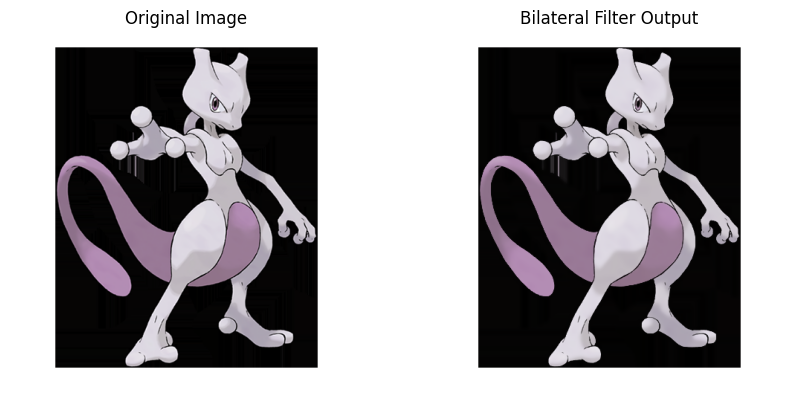

In [35]:
# apply Bilateral Filtering.
bilateral_blur = cv.bilateralFilter(mewtwo_rgb, 9, 75, 75)

# display results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(mewtwo_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(bilateral_blur)
plt.title("Bilateral Filter Output")
plt.axis('off')

plt.show()


##Hough Transform and Edge Detection

Download the image in the given drive link. Save it in your own drive.

https://drive.google.com/file/d/1u3Mqsj-tltJLAQeljHDpK_PX0n3AgoNa/view?usp=sharing

Our task is to find all the vertical edges in it.

Some specific steps need to be followed for this, and each step's code reference is easily found online by simple Google searches. So, only theory resources are given for this section, none for implementation.

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

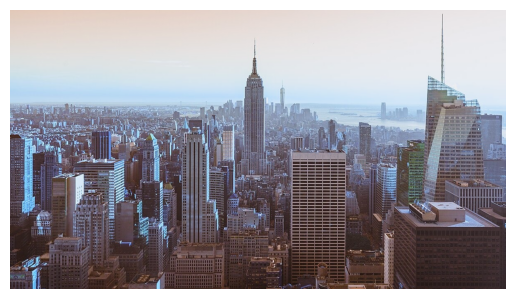

In [36]:
# read the image and display it.

bldg = cv.imread('/content/gdrive/MyDrive/Colab Notebooks/skyline.jpeg')
bldgOG = bldg.copy()

plt.imshow(bldg)
plt.axis('off')

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 1: Convert image to grayscale.

(Note: We usually convert to black and white, but here that would mean loss of vertical edges in the image as they are themselves black. Hence, we don't do that in this case.)

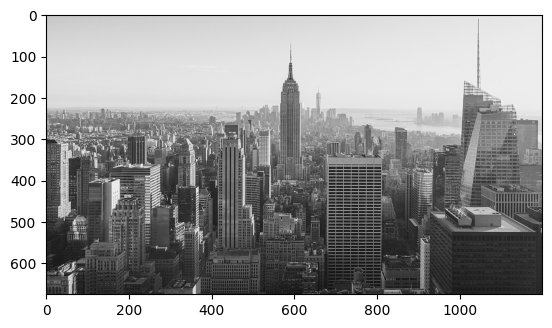

In [38]:
# convert to grayscale and display the image
bldOg_gray = cv.cvtColor(bldgOG, cv.COLOR_BGR2GRAY)

plt.imshow(bldOg_gray, cmap='gray')

Step 2: Apply Gaussian Blur with OpenCV functions.

In [39]:
#Playing with blur - Have 2 sliders to change the blur about X and Y axis

def blur_change(sX, sY):
    blurred = cv.GaussianBlur(bldOg_gray, (0,0), sigmaX=sX, sigmaY=sY)

    plt.figure(figsize=(6,6))
    plt.imshow(blurred, cmap='gray')
    plt.axis('off')
    plt.show()

from ipywidgets import interact
interact(blur_change, sX=(0,10,0.5), sY=(0,10,0.5))

interactive(children=(FloatSlider(value=5.0, description='sX', max=10.0, step=0.5), FloatSlider(value=5.0, des…

<function __main__.blur_change(sX, sY)>

Rule :


Blur more in one direction → Edges perpendicular to that direction get weaker

Blur less in one direction → Edges along that direction stay strong




sigmaX should be way less than sigmaY (sigmaY >> sigmaX)for vertical edges, this allows edge detection about vertical axis to be more easier.
1. Less sigmaX is less Stanrdard Deviation about X axis, making the vertical lines more sharper around X-axis, thus leading to better result in Canny edge detection of vertical edges.
2. Large sigmaY (along with small sigmaX)dominates net gradient to be more vertical and gradient orientation to be precise to 90°, ensuring vertical lines only.

Step 3: Apply Canny Edge detection. Resources:

https://youtu.be/uihBwtPIBxM?si=dzspcgGtKxSAsgV7

https://youtu.be/sRFM5IEqR2w?si=0775wZiBu9uN6lEX

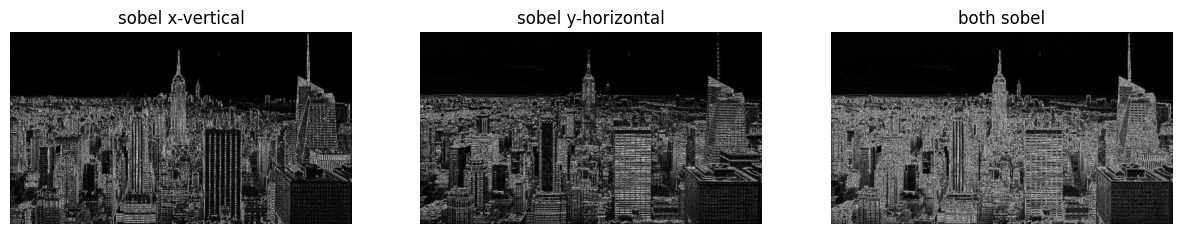

In [40]:
#Edge detection
sobel_x = cv.Sobel(bldOg_gray, cv.CV_64F, 1, 0, ksize=3)
sobel_y = cv.Sobel(bldOg_gray, cv.CV_64F, 0, 1, ksize=3)

sobel_combined = cv.magnitude(sobel_x, sobel_y)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("sobel x-vertical")
plt.imshow(np.uint8(np.absolute(sobel_x)), cmap='gray') #converts sobel result into grayscale values 8 bit unsigned 0-255
plt.axis('off')

plt.subplot(1,3,2)
plt.title("sobel y-horizontal")
plt.imshow(np.uint8(np.absolute(sobel_y)), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("both sobel")
plt.imshow(np.uint8(sobel_combined), cmap='gray')
plt.axis('off')

plt.show()

In [41]:
#Relationship between threshold values (Hysterisis thresholding) and vertical edges

def threshold_change(t1, t2):
    edges = cv.Canny(bldOg_gray, threshold1=t1, threshold2=t2)

    plt.figure(figsize=(12,6))
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    plt.title(f"Threshold1: {t1}, Threshold2: {t2}")
    plt.show()

interact(threshold_change, t1=(0,100,1), t2=(100,200,2))





interactive(children=(IntSlider(value=50, description='t1'), IntSlider(value=150, description='t2', max=200, m…

<function __main__.threshold_change(t1, t2)>

In [42]:
# apply canny edge detection and show image.


Step 4: Now, we use the HoughLinesP (probabilistic hough transform) for actual vertical line detection. Resources:

https://youtu.be/4zHbI-fFIlI?si=RkV_z7FE6iLKYLQV

https://www.analyticsvidhya.com/blog/2022/06/a-complete-guide-on-hough-transform/

Vertical Line: (0, 234) - (23, 674)
Vertical Line: (0, 227) - (31, 674)
Vertical Line: (0, 253) - (7, 674)
Total vertical lines detected: 3


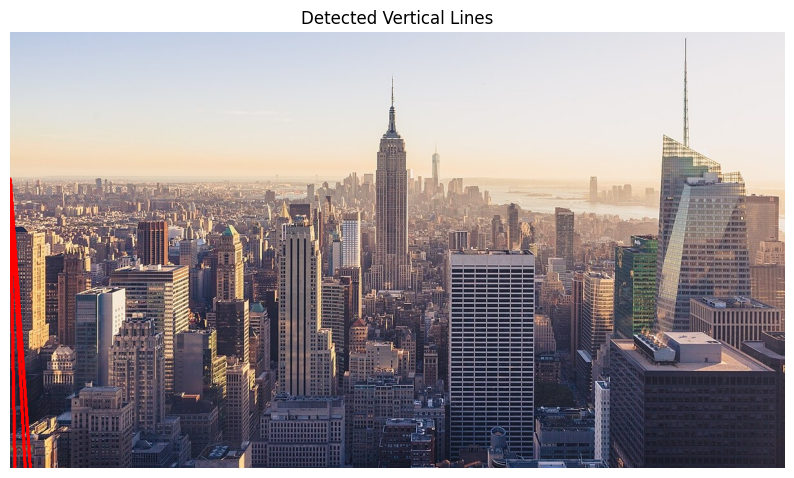

In [43]:
# Detect vertical lines using Probabilistic Hough Transform

lines = cv.HoughLinesP(
    image=bldOg_gray,   # Canny image
    rho=1,               # distance resolution (pixels)
    theta=np.pi/180,     # angle resolution (1 degree)
    threshold=100,       # minimum votes needed
    minLineLength=50,    # minimum length of a line
    maxLineGap=10        # maximum allowed gap to still form a line
)

# Initialize list for storing only vertical line coordinates
coordinates = []

# Loop through detected lines
for lin in lines:
    x1, y1, x2, y2 = lin[0]     # unpack coordinates

    # Calculate the angle of the line
    angle = np.arctan2((y2 - y1), (x2 - x1)) * 180 / np.pi

    # Filter: if angle is ~90° → vertical line
    if abs(angle) > 85:  # allow slight tilt tolerance
        coordinates.append((x1, y1, x2, y2))

        # Draw vertical line on the original image
        cv.line(bldgOG, (x1, y1), (x2, y2), (0,0,255), 3)

# Print all vertical lines + number of lines found
count = 0
for x1, y1, x2, y2 in coordinates:
    print(f"Vertical Line: ({x1}, {y1}) - ({x2}, {y2})")
    count += 1

print("Total vertical lines detected:", count)


plt.figure(figsize=(10,6))
plt.imshow(cv.cvtColor(bldgOG, cv.COLOR_BGR2RGB))
plt.title("Detected Vertical Lines")
plt.axis('off')
plt.show()



Let us see our final results on our original image.

Play around with the above code snippets in new cells to obtain even better results for detecting vertical edges.

In [44]:
# playground.



# Morphological Transformations

references : https://www.youtube.com/watch?v=xSzsD4kXhRw&t=960s, https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html


Steps in the code:
*   Load the image
*   Convert to grayscale
*   Apply thresholding to convert the image to binary (black and white)
*   Apply morphological operations like erosion, dilation, opening, and closing





Why do you think it's necessary to perform morphological transformations?

1. One of the major advantage of morphological transformations is Noise reduction. Using morphological operations like dilation and erosion, one can reduce noise like unnecessary details around subjects which will enhance the quality of the image.
2. Separation of subjects and elements can be achieved using morphological operations, thus making differentiation of objects becomes easier due to enhancement around borders.
3. It is also useful in dividing an image into multiple segments or regions with similar properties.

These factors will play an important role after pre-processing and specific application of user in image processing.

Download image: https://drive.google.com/file/d/1j6IPAheD146pqW-GZ_gGgaCVgUnEWC0z/view?usp=sharing

In [45]:
# Load and display the image


In [46]:
# Convert to grayscale


In [47]:
# apply thresholding


In [48]:
# Define a kernel (5x5 kernel)


In [49]:
# test out the morphological transformations

#Erosion: Some pixels around boundary are discarded, leading to a thinner subject(s) as compared to OG image


#Dilation: Some pixels around the boundary are added, leading to a thicker subject(s) as compared to OG image


#Opening: Erosion + dilation = Erosion followed by dilation


#Closing: Dilation + erosion = Dilation followed by erosion


#Morphological gradient: Difference between dilation and erosion of an image


#Top hat: Difference between input image and Opening of the image



# **Bonus: To be done only if you have completed the above tasks.**

You can research and create a short blog on the topic of thresholding in image processing and what are the different kinds of thresholding.

The best research will be edited and featured on the Synapse Instagram and LinkedIn page. Happy coding! :)

# **End of Task**

> ©Synapse 2025 - 2026

